In [1]:
"""
NB09_Threshold_Sensitivity_Sweep

Purpose
-------
Quantify how the encounter-based framework's outputs depend on
the gating threshold (Section 5.4 sensitivity analysis).

For each percentile in [P90, P75, P50, P25, P10]:
  1) Re-run encounter detection (NB04 logic) on the same NB03 data.
  2) Re-run per-encounter and gated-net Δe integration (NB05 logic).
  3) Record: K encounters, capture fraction, eta, dh_max_net, dh_max_full.

The full-orbit integral (de2d_full) is threshold-independent and serves
as the reference. Capture fraction = ||de2d_net|| / ||de2d_full||.

Dependencies: NB03 artifact, NB05 artifact (for de2d_full, F_amp, basis)
"""

from __future__ import annotations

import json
import numpy as np
from pathlib import Path
from datetime import datetime, timezone

import matplotlib.pyplot as plt

In [2]:
# ============================================================
# Cell 1 : Auto-discover and Load
# ============================================================
ART_DIR = Path("./artifacts")

nb03_files = sorted(ART_DIR.glob("dg_samples_NB03_*_L*.npz"))
nb05_files = sorted(ART_DIR.glob("deltae_NB05_*.npz"))
if not nb03_files: raise FileNotFoundError("No NB03 artifact.")
if not nb05_files: raise FileNotFoundError("No NB05 artifact.")

DG_NPZ   = nb03_files[-1]
NB05_NPZ = nb05_files[-1]

RUN_TAG  = datetime.now(timezone.utc).strftime("NB09_%Y%m%dT%H%M%SZ")
OUT_NPZ  = ART_DIR / f"threshold_sweep_{RUN_TAG}.npz"
OUT_JSON = ART_DIR / f"threshold_sweep_{RUN_TAG}.json"

# Load NB03 perturbation data
dg = np.load(DG_NPZ, allow_pickle=False)
t       = dg["t"].astype(float)
r_eci   = dg["r_eci"].astype(float)
v_eci   = dg["v_eci"].astype(float)
AR      = dg["AR"].astype(float)
AT      = dg["AT"].astype(float)
dg_mag  = dg["dg_mag"].astype(float) if "dg_mag" in dg else np.sqrt(AR**2 + AT**2 + dg["AN"].astype(float)**2)

# Load NB05 reference values (threshold-independent)
nb5 = np.load(NB05_NPZ, allow_pickle=False)
de2d_full     = nb5["de2d_full"].astype(float)
de2d_full_norm = float(np.linalg.norm(de2d_full))
dh_max_full   = float(nb5["dh_max_full"])
F_amp         = float(nb5["F_amp"])
p_hat         = nb5["p_hat"].astype(float)
q_hat         = nb5["q_hat"].astype(float)
nu_pq         = nb5["nu_pq"].astype(float)
de2d_per_nu   = nb5["de2d_per_nu"].astype(float)

M = t.size
nu = nu_pq

# Percentiles to sweep
PERCENTILES = [90.0, 75.0, 50.0, 25.0, 10.0]

# Gating parameters (fixed across sweep)
SMOOTH_WIN = 31
MIN_LEN    = 20
MERGE_GAP  = 10

print(f"NB03: {DG_NPZ.name}")
print(f"NB05: {NB05_NPZ.name}")
print(f"M = {M}   F = {F_amp:.4f} km")
print(f"Full-orbit: ||de2d|| = {de2d_full_norm:.6e}  dh = {dh_max_full*1000:.2f} m")
print(f"Sweep percentiles: {PERCENTILES}")

NB03: dg_samples_NB03_20260316T033826Z_L200.npz
NB05: deltae_NB05_20260316T125355Z.npz
M = 4000   F = 1787.4000 km
Full-orbit: ||de2d|| = 2.781591e-04  dh = 497.18 m
Sweep percentiles: [90.0, 75.0, 50.0, 25.0, 10.0]


In [3]:
# ============================================================
# Cell 2 : Gating and Integration Functions (from NB04/NB05)
# ============================================================

def moving_average(x, w):
    if w <= 1: return x.copy()
    w = int(w); kernel = np.ones(w) / w; pad = w // 2
    return np.convolve(np.pad(x, (pad, pad), mode="edge"), kernel, mode="valid")

def mask_to_segments(mask):
    idx = np.flatnonzero(mask)
    if idx.size == 0: return []
    segs = []; s = prev = idx[0]
    for k in idx[1:]:
        if k == prev + 1: prev = k
        else: segs.append([int(s), int(prev)]); s = prev = k
    segs.append([int(s), int(prev)])
    return segs

def merge_close_segments(segs, gap):
    if not segs: return []
    segs = sorted(segs, key=lambda ab: ab[0])
    out = [list(segs[0])]
    for a, b in segs[1:]:
        if a <= out[-1][1] + gap + 1: out[-1][1] = max(out[-1][1], b)
        else: out.append([a, b])
    return out

def filter_min_len(segs, min_len):
    return [[a, b] for a, b in segs if (b - a + 1) >= min_len]

def handle_wraparound(segs, M, gap):
    if len(segs) < 2: return segs
    segs = sorted(segs, key=lambda ab: ab[0])
    first, last = segs[0], segs[-1]
    if (M - 1 - last[1]) + first[0] <= gap:
        return [[last[0], first[1]]] + segs[1:-1]
    return segs

def segment_indices(a, b, M):
    if a <= b: return np.arange(a, b + 1)
    return np.concatenate([np.arange(a, M), np.arange(0, b + 1)])

print("Gating and integration functions defined.")

Gating and integration functions defined.


In [4]:
# ============================================================
# Cell 3 : Run Sweep
# ============================================================
# Smooth once (threshold-independent)
metric_s = moving_average(dg_mag, SMOOTH_WIN)

sweep_results = []

for pct in PERCENTILES:
    # Gate
    thr = float(np.percentile(metric_s, pct))
    mask = metric_s >= thr
    gated_fraction = float(mask.mean())

    # Segment
    segs = mask_to_segments(mask)
    segs = merge_close_segments(segs, MERGE_GAP)
    segs = handle_wraparound(segs, M, MERGE_GAP)
    segs = filter_min_len(segs, MIN_LEN)
    K = len(segs)

    # Integrate per-encounter
    de2d_enc = np.zeros((K, 2))
    for i, (a, b) in enumerate(segs):
        idx = segment_indices(a, b, M)
        de2d_enc[i, 0] = float(np.trapezoid(de2d_per_nu[idx, 0], x=nu[idx]))
        de2d_enc[i, 1] = float(np.trapezoid(de2d_per_nu[idx, 1], x=nu[idx]))

    # Gated net
    de2d_net = np.sum(de2d_enc, axis=0)
    de2d_net_norm = float(np.linalg.norm(de2d_net))
    dh_net = F_amp * de2d_net_norm

    # Per-encounter norms
    enc_norms = np.linalg.norm(de2d_enc, axis=1)
    sum_norms = float(np.sum(enc_norms))

    # Diagnostics
    eta = de2d_net_norm / max(1e-30, sum_norms)
    capture = de2d_net_norm / max(1e-30, de2d_full_norm)

    # Total gated samples
    total_gated = sum(len(segment_indices(a, b, M)) for a, b in segs)

    sweep_results.append({
        "percentile":       pct,
        "threshold":        thr,
        "K_encounters":     K,
        "gated_samples":    total_gated,
        "gated_fraction":   round(total_gated / M, 4),
        "de2d_net_norm":    de2d_net_norm,
        "dh_net_m":         dh_net * 1000,
        "sum_enc_norms":    sum_norms,
        "dh_sum_m":         sum_norms * F_amp * 1000,
        "eta":              round(eta, 4),
        "capture_fraction": round(capture, 4),
    })

# Print table
print(f"{'='*100}")
print(f"  THRESHOLD SENSITIVITY SWEEP")
print(f"  Full-orbit reference: ||de2d_full||={de2d_full_norm:.6e}  dh_full={dh_max_full*1000:.2f} m")
print(f"{'='*100}")
print(f"{'Pctl':>5s}  {'K':>3s}  {'Gated%':>7s}  {'||de_net||':>11s}  {'dh_net[m]':>10s}  {'dh_sum[m]':>10s}  {'eta':>6s}  {'Capture':>8s}")
print(f"{'-'*5}  {'-'*3}  {'-'*7}  {'-'*11}  {'-'*10}  {'-'*10}  {'-'*6}  {'-'*8}")
for r in sweep_results:
    print(f"{r['percentile']:5.0f}  {r['K_encounters']:3d}  {r['gated_fraction']*100:6.1f}%  "
          f"{r['de2d_net_norm']:11.4e}  {r['dh_net_m']:10.2f}  {r['dh_sum_m']:10.2f}  "
          f"{r['eta']:6.4f}  {r['capture_fraction']*100:7.1f}%")

  THRESHOLD SENSITIVITY SWEEP
  Full-orbit reference: ||de2d_full||=2.781591e-04  dh_full=497.18 m
 Pctl    K   Gated%   ||de_net||   dh_net[m]   dh_sum[m]     eta   Capture
-----  ---  -------  -----------  ----------  ----------  ------  --------
   90    4     9.2%   5.1118e-05       91.37      902.49  0.1012     18.4%
   75    8    24.1%   1.5765e-04      281.78     2267.22  0.1243     56.7%
   50    8    48.5%   3.4256e-04      612.30     3866.59  0.1584    123.2%
   25    8    64.7%   2.9543e-04      528.04     4081.78  0.1294    106.2%
   10    6    76.4%   1.1281e-04      201.64     4461.34  0.0452     40.6%


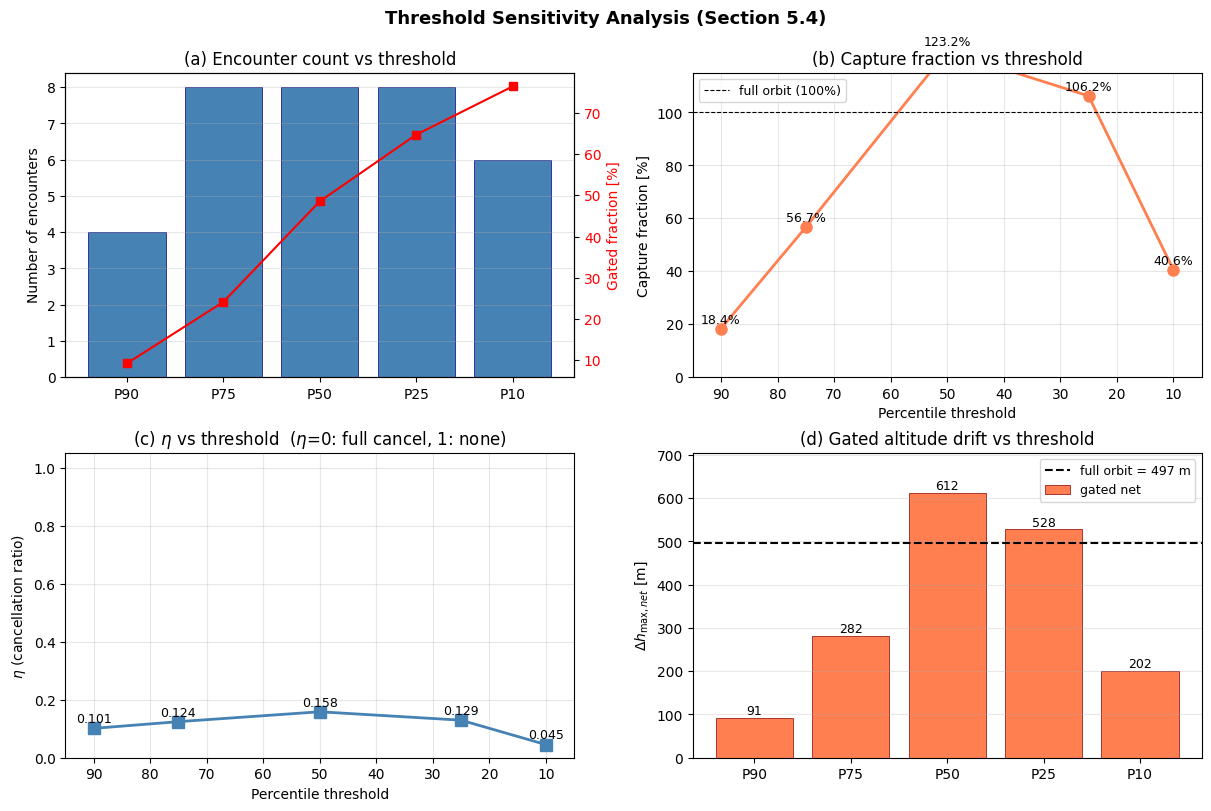

In [5]:
# ============================================================
# Cell 4 : Plots
# ============================================================
pcts = [r["percentile"] for r in sweep_results]
Ks   = [r["K_encounters"] for r in sweep_results]
caps = [r["capture_fraction"] * 100 for r in sweep_results]
etas = [r["eta"] for r in sweep_results]
dhs  = [r["dh_net_m"] for r in sweep_results]
gf   = [r["gated_fraction"] * 100 for r in sweep_results]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# (a) Encounter count + gated fraction
ax = axes[0, 0]
ax.bar(range(len(pcts)), Ks, color="steelblue", edgecolor="navy", lw=0.5)
ax.set_xticks(range(len(pcts))); ax.set_xticklabels([f"P{int(p)}" for p in pcts])
ax.set_ylabel("Number of encounters")
ax.set_title("(a) Encounter count vs threshold")
ax.grid(True, axis="y", alpha=0.3)
ax2 = ax.twinx()
ax2.plot(range(len(pcts)), gf, "rs-", ms=6, lw=1.5)
ax2.set_ylabel("Gated fraction [%]", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# (b) Capture fraction
ax = axes[0, 1]
ax.plot(pcts, caps, "o-", color="coral", lw=2, ms=8)
ax.axhline(100, color="k", ls="--", lw=0.8, label="full orbit (100%)")
for i, (p, c) in enumerate(zip(pcts, caps)):
    ax.text(p, c + 2, f"{c:.1f}%", ha="center", fontsize=9)
ax.set_xlabel("Percentile threshold")
ax.set_ylabel("Capture fraction [%]")
ax.set_title("(b) Capture fraction vs threshold")
ax.set_xlim(95, 5); ax.set_ylim(0, 115)
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

# (c) Cancellation eta
ax = axes[1, 0]
ax.plot(pcts, etas, "s-", color="steelblue", lw=2, ms=8)
for i, (p, e) in enumerate(zip(pcts, etas)):
    ax.text(p, e + 0.02, f"{e:.3f}", ha="center", fontsize=9)
ax.set_xlabel("Percentile threshold")
ax.set_ylabel(r"$\eta$ (cancellation ratio)")
ax.set_title(r"(c) $\eta$ vs threshold  ($\eta$=0: full cancel, 1: none)")
ax.set_xlim(95, 5); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# (d) Altitude drift: gated net vs full
ax = axes[1, 1]
ax.bar(range(len(pcts)), dhs, color="coral", edgecolor="darkred", lw=0.5, label="gated net")
ax.axhline(dh_max_full * 1000, color="k", ls="--", lw=1.5, label=f"full orbit = {dh_max_full*1000:.0f} m")
for i, (d) in enumerate(dhs):
    ax.text(i, d + 8, f"{d:.0f}", ha="center", fontsize=9)
ax.set_xticks(range(len(pcts))); ax.set_xticklabels([f"P{int(p)}" for p in pcts])
ax.set_ylabel(r"$\Delta h_{\max,net}$ [m]")
ax.set_title("(d) Gated altitude drift vs threshold")
ax.set_ylim(0, max(dh_max_full * 1000 * 1.15, max(dhs) * 1.15))
ax.grid(True, axis="y", alpha=0.3); ax.legend(fontsize=9)

fig.suptitle("Threshold Sensitivity Analysis (Section 5.4)", fontsize=13, fontweight="bold")
plt.show()

In [6]:
# ============================================================
# Cell 5 : Save
# ============================================================
meta = {
    "run_tag":      RUN_TAG,
    "nb03_npz":     str(DG_NPZ),
    "nb05_npz":     str(NB05_NPZ),
    "percentiles":  PERCENTILES,
    "gate_params":  {"smooth_win": SMOOTH_WIN, "min_len": MIN_LEN, "merge_gap": MERGE_GAP},
    "reference":    {"de2d_full_norm": de2d_full_norm, "dh_max_full_m": dh_max_full * 1000},
    "sweep":        sweep_results,
}

np.savez(OUT_NPZ,
    percentiles=np.array(PERCENTILES),
    K_encounters=np.array([r["K_encounters"] for r in sweep_results]),
    capture_fraction=np.array([r["capture_fraction"] for r in sweep_results]),
    eta=np.array([r["eta"] for r in sweep_results]),
    dh_net_m=np.array([r["dh_net_m"] for r in sweep_results]),
    dh_full_m=dh_max_full * 1000,
    meta_json=json.dumps(meta),
)
OUT_JSON.write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"Saved: {OUT_NPZ}")
print(f"Saved: {OUT_JSON}")
print(f"\n--- NB09 complete ---")

Saved: artifacts\threshold_sweep_NB09_20260316T141909Z.npz
Saved: artifacts\threshold_sweep_NB09_20260316T141909Z.json

--- NB09 complete ---
